In [4]:
import numpy as np

#Task 1:
arr = np.ones([5,5])
arr[1:4,1:4]=0

print(arr)

#Task 2:
np.random.seed(42)
random_data= np.random.randn(100,3)
normalized_data = (
    random_data - random_data.mean(axis=0)) / random_data.std(axis=0)

print(normalized_data)
# Task 3:
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

print("Estimated coefficients:")
print(theta_hat)

print("\nTrue coefficients:")
print(true_theta)




[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]
[[ 4.93439239e-01  4.61603061e-02  5.17340053e-01]
 [ 1.74402998e+00 -5.22690072e-02 -2.79011884e-01]
 [ 1.81249029e+00  9.75852610e-01 -4.91538532e-01]
 [ 5.49303576e-01 -2.87606868e-01 -4.88156860e-01]
 [ 1.83017852e-01 -1.77587837e+00 -1.62529439e+00]
 [-7.96980164e-01 -8.51575049e-01  2.16218628e-01]
 [-1.21826859e+00 -1.26163023e+00  1.25601706e+00]
 [-3.86933017e-01  2.57404552e-01 -1.35421958e+00]
 [-7.75162723e-01  3.01948517e-01 -1.10699945e+00]
 [ 3.45978124e-01 -4.28463047e-01 -3.30989813e-01]
 [-8.45013279e-01  2.08943513e+00 -7.97583137e-02]
 [-1.40066567e+00  1.03242274e+00 -1.17007910e+00]
 [ 1.42686307e-01 -1.82349718e+00 -1.26701701e+00]
 [ 1.28061139e-01  9.46117052e-01  8.71885533e-02]
 [-2.52739338e-01 -1.20992939e-01 -1.40278120e+00]
 [-9.88966824e-01 -2.84754328e-01  8.87088163e-01]
 [ 3.06888192e-01 -1.62165820e+00  2.25101819e-01]
 [-5.81051242e-01 -5.06767212e-01  4.84818

In [5]:
import pandas as pd

import numpy as np
# Create sample dataset

np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

print("First 5 Rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nSummary Statistics:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())


majors = df['major'].unique()
for major in majors:
    mean_score = df[df['major'] == major]['exam_score'].mean()
    df.loc[
        (df['major'] == major) &
        (df['exam_score'].isnull()),
        'exam_score'
    ] = mean_score
    years = df['year'].unique()

for year in years:
    median_hours = df[df['year'] == year]['hours_studied'].median()
    df.loc[
        (df['year'] == year) &
        (df['hours_studied'].isnull()),
        'hours_studied'
    ] = median_hours

average_scores = df.groupby('major')['exam_score'].mean()

print("\nAverage Exam Score By Major:")

print(average_scores)

best_major = average_scores.idxmax()

print("\nMajor With Highest Average Score:")

print(best_major)

correlation = df['hours_studied'].corr(df['exam_score'])

print("\nCorrelation Between Hours Studied and Exam Score:")

print(correlation)

def performance(score):
    if score > 90:
        return "Excellent"
    elif score >= 80:
        return "Good"
    elif score >= 70:
        return "Average"
    else:
        return "Needs Improvement"

df['performance'] = df['exam_score'].apply(performance)

print("\nPerformance Categories:")

print(df[['exam_score', 'performance']].head())


# Task 3:
major_year = df.groupby(['major', 'year']).agg({
    'student_id': 'count',
    'exam_score': 'mean',
    'hours_studied': 'mean'
})
print("\nMajor-Year Analysis:")
print(major_year)

top_5 = df.sort_values(
    by='exam_score',
    ascending=False
).head(5)

print("\nTop 5 Students:")
print(top_5[['student_id', 'major', 'exam_score']])

pivot = pd.pivot_table(
    df,
    values='exam_score',
    index='major',
    columns='year',
    aggfunc='mean'
)

print("\nPivot Table:")
print(pivot)

First 5 Rows:
   student_id    major  year  exam_score  assignments_completed  hours_studied
0        1000  Physics     3   68.199753                     10            NaN
1        1001  Biology     4   77.322537                      9      12.204873
2        1002       CS     3   77.930725                      9       7.829556
3        1003  Physics     1   67.856486                      2      14.042336
4        1004  Physics     4   93.657745                      6      15.287370

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    str    
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null

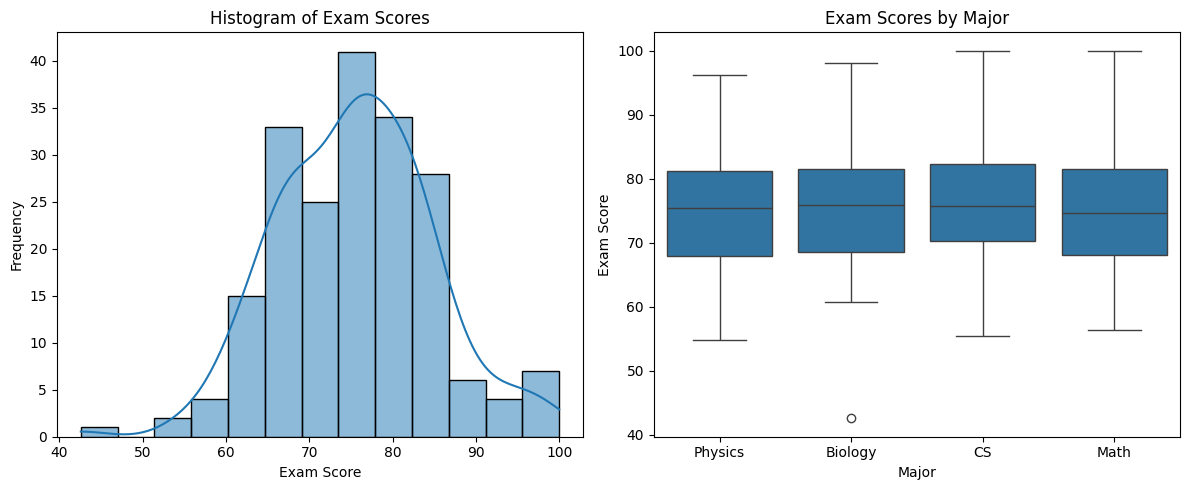

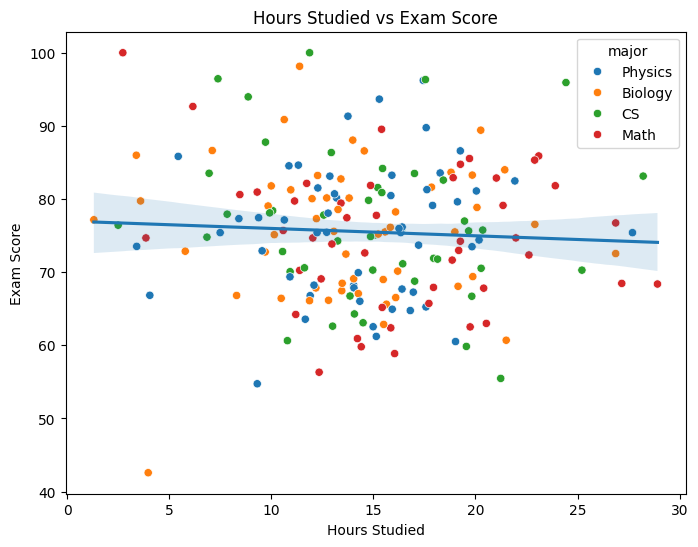

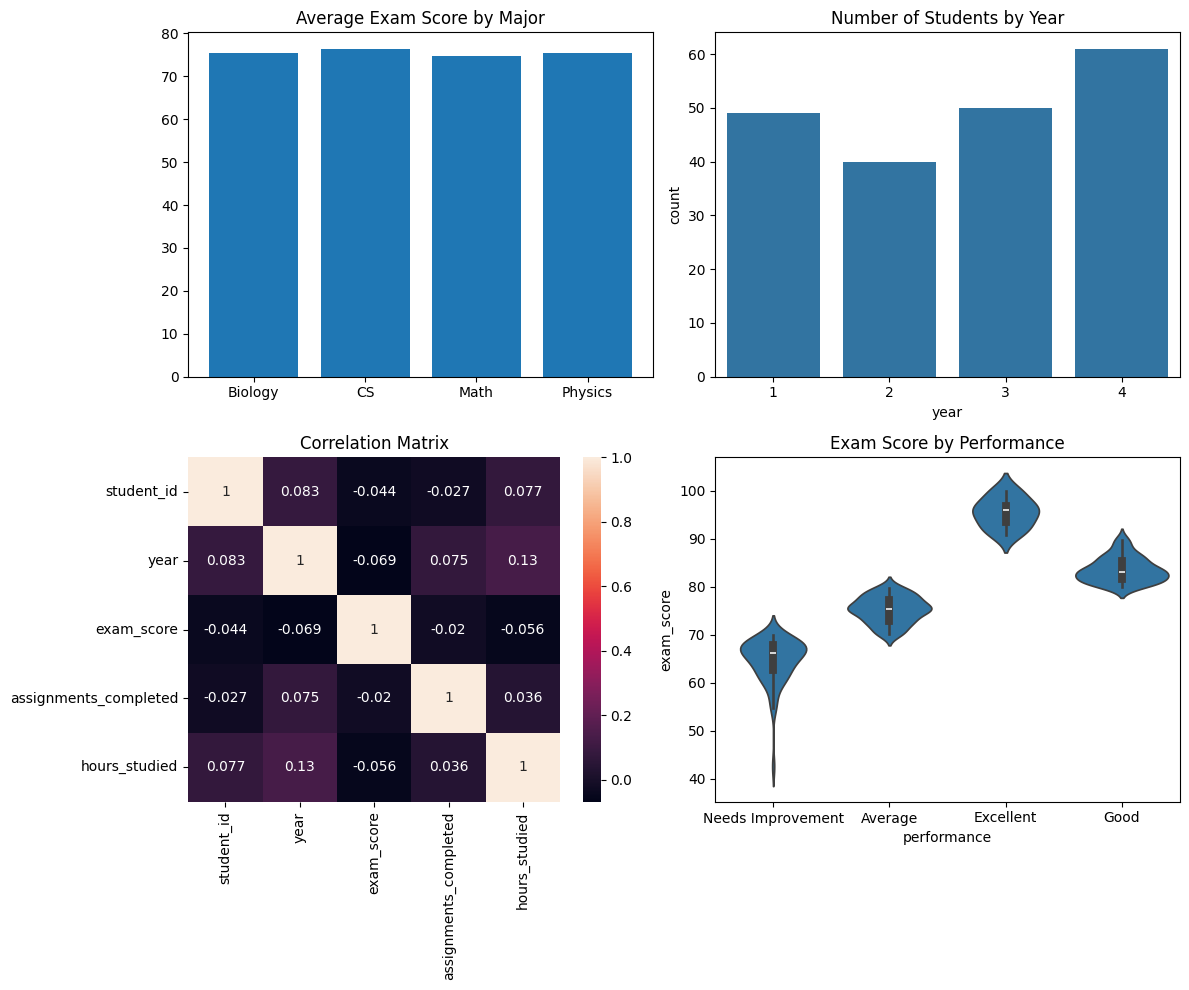

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1

plt.figure(figsize=(12,5))

# Histogram
plt.subplot(1,2,1)
sns.histplot(df["exam_score"], kde=True)
plt.title("Histogram of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")

# Box Plot
plt.subplot(1,2,2)
sns.boxplot(x="major", y="exam_score", data=df)
plt.title("Exam Scores by Major")
plt.xlabel("Major")
plt.ylabel("Exam Score")

plt.tight_layout()
plt.show()

# Task 2
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="hours_studied",
    y="exam_score",
    hue="major",
    data=df
)

sns.regplot(
    x="hours_studied",
    y="exam_score",
    data=df,
    scatter=False
)

plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.show()

# Task 3
plt.figure(figsize=(12,10))

plt.subplot(2,2,1)

average_scores = df.groupby("major")["exam_score"].mean()

plt.bar(
    average_scores.index,
    average_scores.values
)
plt.title("Average Exam Score by Major")

plt.subplot(2,2,2)
sns.countplot(x="year", data=df)
plt.title("Number of Students by Year")


plt.subplot(2,2,3)
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True)
plt.title("Correlation Matrix")

plt.subplot(2,2,4)
sns.violinplot(
    x="performance",
    y="exam_score",
    data=df
)
plt.title("Exam Score by Performance")
plt.tight_layout()
plt.show()

Summary By Age Group
            age        income         CLV               
          count          mean        mean            sum
age_group                                               
18-25        69  51805.879852  704.492597   48609.989225
26-35        73  48747.148046  747.738562   54584.915035
36-50       160  48516.895668  732.796612  117247.457917
51-70       186  50713.163384  762.693498  141860.990683

Top 10% Customers
     age        income  purchase_frequency  avg_purchase_value  churn_risk  \
426   42  68713.567863                   8          154.285448    0.333333   
213   41  45580.608009                   7          164.920221    0.416667   
410   44  49344.934596                   6          177.097211    0.500000   
194   44  57331.964922                   6          176.640590    0.500000   
244   28  29255.076913                   7          159.784979    0.416667   
423   43  34443.666248                   6          173.245130    0.500000   
386   63  24200

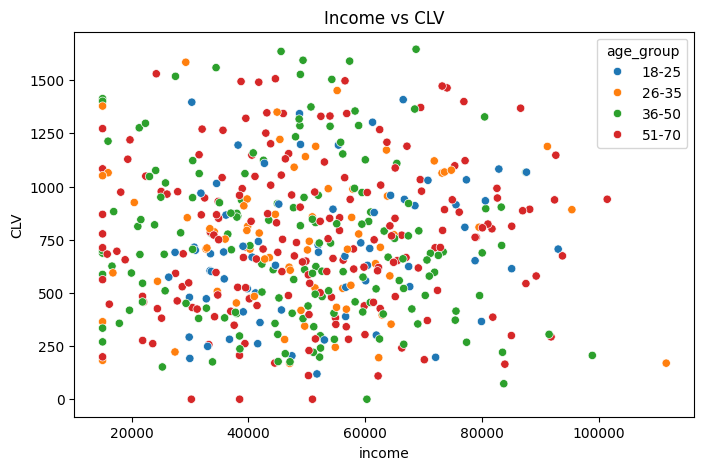

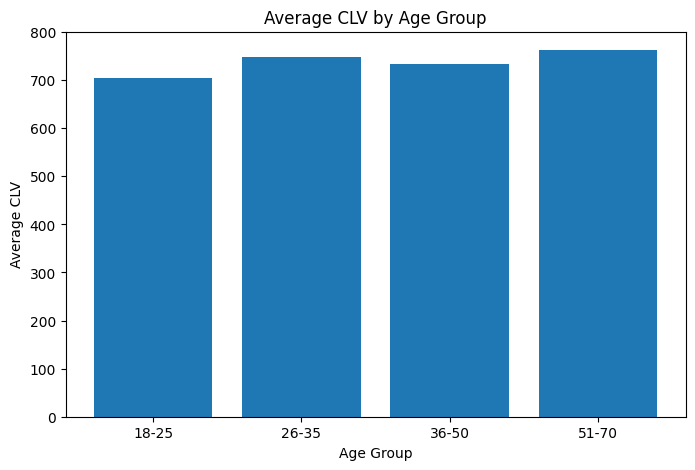

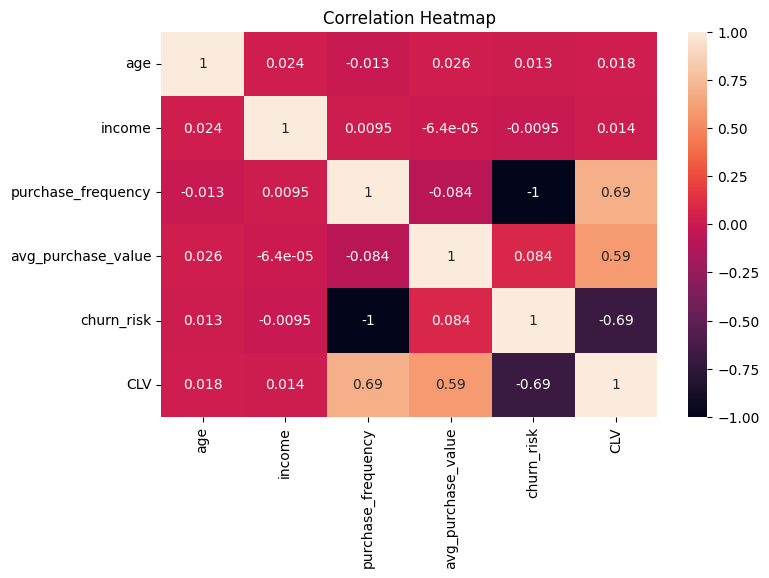

In [7]:
"""
Exercise 7: Integration Challenge
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.
"""

# Scenario: You're analyzing customer data for an e-commerce company.
# Generate synthetic data and provide insights.

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# Customer Lifetime Value (CLV)

max_frequency = customers["purchase_frequency"].max()

customers["churn_risk"] = (
    1 - customers["purchase_frequency"] / max_frequency
)

customers["CLV"] = (
    customers["purchase_frequency"]
    * customers["avg_purchase_value"]
    * (1 + customers["churn_risk"])
)
# Age Groups
customers["age_group"] = pd.cut(
    customers["age"],
    bins=[18, 25, 35, 50, 70],
    labels=["18-25", "26-35", "36-50", "51-70"]
)

# Summary Statistics
summary = customers.groupby("age_group").agg({
    "age": "count",
    "income": "mean",
    "CLV": ["mean", "sum"]
})

print("Summary By Age Group")
print(summary)

# Top 10% Customers
top_customers = customers.sort_values(
    by="CLV",
    ascending=False
).head(50)
print("\nTop 10% Customers")
print(top_customers)

# Scatter Plot
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=customers,
    x="income",
    y="CLV",
    hue="age_group"
)
plt.title("Income vs CLV")
plt.show()

# Average CLV by Age Group
average_clv = customers.groupby(
    "age_group"
)["CLV"].mean()
plt.figure(figsize=(8,5))

plt.bar(
    average_clv.index,
    average_clv.values
)

plt.title("Average CLV by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average CLV")

plt.show()

# Correlation Heatmap

correlation_matrix = customers.corr(
    numeric_only=True
)
plt.figure(figsize=(8,5))
sns.heatmap(
    correlation_matrix,
    annot=True
)
plt.title("Correlation Heatmap")
plt.show()